#  Augmentasi Data Deteksi Emosi Bahasa Indonesia (REVISI - Base Model)

**Model:** `meta-llama/Meta-Llama-3-8B` (Base, bukan Instruct)
**Metode:** Few-shot completion paraphrasing (label-preserving)
**Target:** 2100 sample per label emosi
**Label:** `joy`, `sad`, `anger`, `fear`, `love`, `neutral`

---

###  Catatan Revisi

Notebook ini menggunakan **base model** (`Meta-Llama-3-8B`, bukan `-Instruct`). Karena base
model tidak di-fine-tune untuk mengikuti instruksi (system prompt), pendekatan prompting-nya
sengaja dibuat berbeda dari versi Instruct:

1. **Few-shot completion, bukan instruksi.** Base model bekerja dengan cara melanjutkan pola
   teks, bukan "memahami perintah". Maka prompt dibangun sebagai beberapa **contoh pasangan
   tweet asli -> hasil parafrase** yang polanya konsisten, lalu diakhiri dengan tweet target.
   Model akan cenderung meniru pola dari contoh (format, tanpa tanda kutip, satu baris per
   parafrase) alih-alih diberi tahu lewat instruksi eksplisit yang mungkin tidak dipatuhi.
2. **`tokenizer.apply_chat_template()` TIDAK dipakai** di versi ini, karena base model umumnya
   tidak memiliki `chat_template` terdefinisi (akan error jika dipaksakan). Prompt dibangun
   sebagai string biasa (plain-text completion prompt).
3. **Ekstraksi hasil generate tetap berbasis TOKEN**, bukan string slicing -- fix ini tetap
   dipertahankan dari revisi sebelumnya karena bug-nya (`full_output[len(prompt):]` meleset
   karakter) tidak spesifik ke base/instruct, melainkan ke cara ekstraksi string vs token.
   Karena tokenizer diset `padding_side="left"`, panjang token prompt (`prompt_len`) selalu
   sama untuk semua baris dalam satu batch, sehingga token hasil generate bisa dipotong
   dengan presisi via `output_ids[prompt_len:]`.
4. **Pembersihan hasil generate** (`clean_generated_text`) tetap dipertahankan sebagai jaring
   pengaman -- mengambil baris pertama saja dan membuang tanda kutip yang nyelip -- karena
   base model masih mungkin meniru pola tanda kutip dari data pretraining meskipun sudah
   dipandu contoh few-shot.
5. **Tidak ada penanganan token `<|eot_id|>`** seperti versi Instruct, karena token itu bagian
   dari chat template Instruct dan tidak relevan untuk base model. Base model jarang
   menghasilkan EOS di tengah dokumen, sehingga generation akan sering berjalan sampai
   `max_new_tokens` -- ini normal, dan pemotongan baris pertama (`clean_generated_text`)
   yang menjaga hasil akhir tetap berupa satu tweet saja.

>  **Karena base model kurang reliable dibanding Instruct dalam mengikuti gaya/format,**
> disarankan mengecek lebih banyak sample hasil augmentasi secara manual (lihat cell QA di
> akhir notebook) dan menaikkan `max_retries` bila proporsi output yang gagal validasi tinggi.

---

###  Alur Pipeline
1. Install & import library
2. Load dataset CSV
3. Tampilkan distribusi label awal
4. Identifikasi kelas yang perlu diaugmentasi
5. Buat prompt few-shot (contoh + target) untuk augmentasi
6. Generate data baru menggunakan Llama-3-8B (Base)
7. Ekstraksi hasil generate berbasis token + pembersihan teks
8. Filter duplicate & validasi kualitas output
9. Gabungkan dataset asli dan hasil augmentasi
10. Tampilkan distribusi label akhir
11. Simpan hasil akhir ke CSV baru

>  **Pastikan runtime Google Colab diset ke GPU A100** sebelum menjalankan notebook ini.


---
##  Langkah 1 — Install Library

In [1]:
# Install semua dependensi yang diperlukan
# transformers : load model Llama-3
# bitsandbytes : quantisasi 4-bit agar model muat di VRAM
# accelerate   : distribusi model ke GPU secara otomatis
# pandas, tqdm : manipulasi data dan progress bar

!pip install -q transformers
!pip install -q bitsandbytes
!pip install -q accelerate
!pip install -q pandas tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.7 MB/s eta 0:00:00


In [2]:
# Download dataset from Google Drive
!pip install -q gdown
import gdown

# Google Drive file ID
file_id = "1z3AfTozCLktL35-SH9ukZG-Oxgb06etP"
output = "all_data.csv"

# Download file
gdown.download(f"https://drive.google.com/uc?id={file_id}", output, quiet=False)
print(f"Dataset downloaded: {output}")


Downloading...
From: https://drive.google.com/uc?id=1z3AfTozCLktL35-SH9ukZG-Oxgb06etP
To: /content/all_data.csv
100%|██████████| 794k/794k [00:00<00:00, 159MB/s]

Dataset downloaded: all_data.csv


---
##  Langkah 2 — Import Library & Konfigurasi Global

In [3]:
import os
import time
import random
import warnings
import pandas as pd
import numpy as np
import torch
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
)

warnings.filterwarnings("ignore")

# Suppress transformers warnings
import logging
logging.getLogger('transformers').setLevel(logging.ERROR)
logging.getLogger('transformers.tokenization_utils').setLevel(logging.ERROR)

# --- Seed global agar hasil reproducible di setiap run ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(" Library berhasil diimpor")

 Library berhasil diimpor


In [ ]:
# ============================================================
# KONFIGURASI UTAMA
# Sesuaikan bagian ini sebelum menjalankan pipeline
# ============================================================

CONFIG = {
    # Path file CSV dataset train yang sudah di-split
    "input_csv_path": "all_data.csv",

    # Path output CSV hasil augmentasi
    "output_csv_path": "all_data_augmented.csv",

    # [REVISI] Kembali ke base model (bukan -Instruct).
    # Karena base model, prompting dilakukan via few-shot completion (lihat build_augmentation_prompt),
    # bukan system/user instruction seperti model Instruct.
    "model_name": "meta-llama/Meta-Llama-3-8B",

    # Target jumlah sample per label emosi
    "target_per_label": 2100,

    # Label emosi yang digunakan dalam dataset
    "emotion_labels": ["joy", "sad", "anger", "fear", "love", "neutral"],

    # Jumlah teks yang di-generate dalam satu batch (sesuaikan dengan VRAM)
    "batch_size": 32,

    # Maksimal percobaan ulang jika output tidak valid.
    # [CATATAN] Base model cenderung lebih sering menghasilkan output yang gagal validasi
    # dibanding Instruct (kurang konsisten mengikuti format), jadi nilai ini bisa dinaikkan
    # (mis. 4-5) jika proses augmentasi terasa lambat mencapai target_per_label.
    "max_retries": 3,

    # Parameter generation model
    "generation_config": {
        "temperature": 0.7,   # Kontrol kreativitas (0=deterministik, 1=acak)
        "top_p": 0.9,         # Nucleus sampling: ambil token dari top 90% probabilitas
        "do_sample": True,    # Aktifkan sampling (wajib jika temperature/top_p digunakan)
        "max_new_tokens": 128, # Maksimal token output baru per generasi
    },
}

print(" Konfigurasi berhasil dimuat")
print(f"   Model  : {CONFIG['model_name']}")
print(f"   Target : {CONFIG['target_per_label']} sample/label")
print(f"   Labels : {CONFIG['emotion_labels']}")


---
##  Langkah 3 — Load Dataset CSV

In [5]:
def load_dataset(csv_path: str) -> pd.DataFrame:
    """
    Memuat dataset dari file CSV.
    Memastikan kolom yang diperlukan tersedia (index, tweet, label).
    """
    print(f"\n Memuat dataset dari: {csv_path}")
    df = pd.read_csv(csv_path)

    # Validasi kolom yang diperlukan
    required_cols = {"tweet", "label"}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Kolom berikut tidak ditemukan di CSV: {missing}")

    # Hapus baris dengan nilai kosong pada kolom kunci
    df = df.dropna(subset=["tweet", "label"])

    # Pastikan kolom tweet bertipe string
    df["tweet"] = df["tweet"].astype(str).str.strip()

    # Normalisasi label ke huruf kecil
    df["label"] = df["label"].str.lower().str.strip()

    # Buat kolom index jika belum ada
    if "index" not in df.columns:
        df = df.reset_index(drop=False)  # jadikan index DataFrame sebagai kolom

    print(f" Dataset berhasil dimuat: {len(df)} baris")
    print(f"   Kolom : {list(df.columns)}")
    return df


# Jalankan fungsi load
df_all = load_dataset(CONFIG["input_csv_path"])
df_all.head()


 Memuat dataset dari: all_data.csv
 Dataset berhasil dimuat: 7080 baris
   Kolom : ['index', 'tweet', 'label']


,index,tweet,label
0,0,pagi2 udah di buat emosi :),anger
1,1,"kok stabilitas negara, memange 10 thn negara t...",anger
2,2,dah lah emosi mulu liat emyu,anger
3,3,"aib? bodoh benar! sebelum kata aib itu muncul,...",anger
4,4,dih lu yg nyebelin bego,anger


---
##  Langkah 4 & 5 — Distribusi Label Awal & Kebutuhan Augmentasi


 Distribusi Label AWAL
----------------------------------------
  joy       :  1275
  sad       :  1003
  anger     :  1130
  fear      :   911
  love      :   760
  neutral   :  2001

  Total: 7080 baris


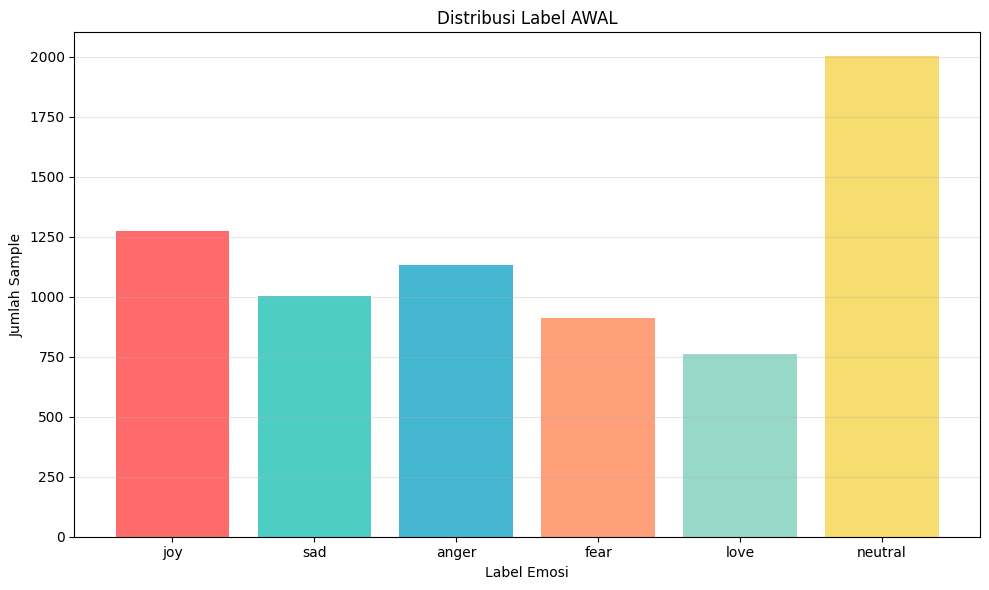


 Target per label: 2100 sample

 Kebutuhan augmentasi:
--------------------------------------------------
  joy       :  1275 saat ini ->   Butuh +825 sample
  sad       :  1003 saat ini ->   Butuh +1097 sample
  anger     :  1130 saat ini ->   Butuh +970 sample
  fear      :   911 saat ini ->   Butuh +1189 sample
  love      :   760 saat ini ->   Butuh +1340 sample
  neutral   :  2001 saat ini ->   Butuh +99 sample


In [6]:
def analyze_distribution(df: pd.DataFrame, title: str = "Distribusi Label") -> dict:
    """
    Menampilkan distribusi jumlah sample per label emosi
    dan mengembalikan dictionary {label: jumlah}.
    """
    print(f"\n {title}")
    print("-" * 40)
    dist = df["label"].value_counts().to_dict()

    # Print text summary
    for label in CONFIG["emotion_labels"]:
        count = dist.get(label, 0)
        print(f"  {label:<10}: {count:>5}")

    print(f"\n  Total: {len(df)} baris")

    # Create bar chart using matplotlib
    labels = CONFIG["emotion_labels"]
    values = [dist.get(label, 0) for label in labels]

    plt.figure(figsize=(10, 6))
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F']
    plt.bar(labels, values, color=colors[:len(labels)])
    plt.title(title)
    plt.xlabel('Label Emosi')
    plt.ylabel('Jumlah Sample')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    return dist

def identify_augmentation_needs(dist: dict) -> dict:
    """
    Mengidentifikasi label mana yang perlu diaugmentasi
    dan berapa jumlah sample tambahan yang dibutuhkan.

    Hanya augmentasi label dengan jumlah < target_per_label.
    Label yang sudah >= target tidak diaugmentasi.
    """
    target = CONFIG["target_per_label"]
    needs = {}

    print(f"\n Target per label: {target} sample")
    print("\n Kebutuhan augmentasi:")
    print("-" * 50)

    for label in CONFIG["emotion_labels"]:
        current = dist.get(label, 0)
        needed = max(0, target - current)
        needs[label] = needed
        status = " Cukup" if needed == 0 else f"  Butuh +{needed} sample"
        print(f"  {label:<10}: {current:>5} saat ini -> {status}")

    return needs


# Tampilkan distribusi awal
dist_awal = analyze_distribution(df_all, title="Distribusi Label AWAL")

# Identifikasi kebutuhan augmentasi
augmentation_needs = identify_augmentation_needs(dist_awal)

---
##  Langkah 6 — Load Model Llama-3-8B-Instruct (4-bit Quantization)

In [7]:
# Cek ketersediaan dan spesifikasi GPU
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    bf16_support = torch.cuda.is_bf16_supported()
    print(f"  GPU terdeteksi : {gpu_name}")
    print(f"   VRAM          : {vram:.1f} GB")
    print(f"   BFloat16      : {' Didukung (optimal untuk A100)' if bf16_support else ' Tidak didukung'}")
else:
    print("  GPU tidak terdeteksi. Proses akan berjalan di CPU (sangat lambat).")
    print("   -> Pastikan runtime Colab diset ke A100 GPU")

  GPU terdeteksi : NVIDIA A100-SXM4-40GB
   VRAM          : 42.4 GB
   BFloat16      :  Didukung (optimal untuk A100)


In [ ]:
from huggingface_hub import login
login()

def load_llama_model():
    """
    Memuat model Llama-3-8B (Base) dengan konfigurasi:
    - Quantisasi 4-bit (NF4) menggunakan bitsandbytes -> hemat VRAM ~4x
    - BFloat16 untuk komputasi (optimal di A100)
    - Accelerate untuk distribusi memori otomatis (device_map='auto')

    [CATATAN] Base model umumnya TIDAK punya tokenizer.chat_template terdefinisi.
    Jangan panggil tokenizer.apply_chat_template() dengan model ini -- akan error.
    Prompting dilakukan via few-shot plain-text completion (lihat build_augmentation_prompt).
    """
    model_name = CONFIG["model_name"]
    print(f"\n Memuat model: {model_name}")
    print(" Proses ini membutuhkan beberapa menit pertama kali (download + load)...")

    # Konfigurasi quantisasi 4-bit untuk efisiensi memori
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,                      # Aktifkan quantisasi 4-bit
        bnb_4bit_quant_type="nf4",              # NormalFloat4: akurasi lebih baik dari int4
        bnb_4bit_compute_dtype=torch.bfloat16,  # BF16 untuk forward pass (A100 optimal)
        bnb_4bit_use_double_quant=True,         # Double quantisasi: hemat ~0.4 bit/param
    )

    # Load tokenizer (kamus kata -> token ID)
    tokenizer = AutoTokenizer.from_pretrained(
        model_name,
        padding_side="left",  # Padding di kiri penting untuk batch generation (causal LM)
        trust_remote_code=True,
    )

    # Tambahkan pad token jika belum ada (Llama-3 default tidak punya pad token)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
        tokenizer.pad_token_id = tokenizer.eos_token_id

    # Load model dengan quantisasi 4-bit
    # Catatan: jangan tambahkan .to() setelah ini — model 4-bit bitsandbytes
    # sudah otomatis ditempatkan ke device yang benar oleh device_map='auto'
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_config,
        device_map="auto",           # Distribusi otomatis ke GPU/CPU
        trust_remote_code=True,
    )

    # CATATAN: jangan panggil model.eval() atau model.to() pada model 4-bit bitsandbytes
    # karena keduanya memicu ValueError. Gunakan torch.inference_mode() saat generate.

    # Deteksi device utama model via hf_device_map (lebih aman untuk model multi-device)
    if hasattr(model, 'hf_device_map') and model.hf_device_map:
        # Ambil device dari layer pertama yang terdaftar
        first_device = list(model.hf_device_map.values())[0]
        model_device = torch.device(f"cuda:{first_device}" if isinstance(first_device, int) else first_device)
    else:
        model_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print("\n Model berhasil dimuat!")
    print(f"   Device    : {model_device}")
    return tokenizer, model, model_device


# Load model dan tokenizer
# model_device digunakan untuk memindahkan input tensor ke GPU secara eksplisit
tokenizer, model, model_device = load_llama_model()

---
##  Langkah 7 — Prompt Template Augmentasi

In [ ]:
# Deskripsi emosi dalam Bahasa Indonesia untuk memperkaya konteks prompt
# Ini membantu model memahami nuansa emosi yang harus dipertahankan
EMOTION_DESCRIPTIONS = {
    "joy":     "kebahagiaan, kesenangan, kegembiraan, atau antusiasme",
    "sad":     "kesedihan, dukacita, kekecewaan, atau rasa kehilangan",
    "anger":   "kemarahan, frustrasi, kejengkelan, atau ketidakpuasan",
    "fear":    "ketakutan, kekhawatiran, kecemasan, atau rasa was-was",
    "love":    "cinta, kasih sayang, rasa suka, atau rasa peduli",
    "neutral": "pernyataan netral tanpa emosi yang menonjol",
}


# [REVISI] Contoh few-shot untuk memandu base model (bukan model Instruct).
# Base model tidak mengikuti instruksi -- dia hanya melanjutkan pola teks.
# Contoh-contoh ini SENGAJA ditulis singkat, natural gaya Twitter, TANPA tanda kutip,
# supaya base model meniru format tersebut alih-alih diberi tahu lewat instruksi eksplisit
# (yang sering diabaikan base model).
FEW_SHOT_EXAMPLES = [
    {
        "label": "joy",
        "original": "akhirnya libur juga, seneng banget rasanyaaa",
        "paraphrase": "yeay akhirnya libur, aku happy bgt gaes",
    },
    {
        "label": "sad",
        "original": "kenapa ya belakangan ini aku ngerasa sedih terus",
        "paraphrase": "entah kenapa akhir-akhir ini hatiku berat mulu, sedih aja gitu",
    },
    {
        "label": "anger",
        "original": "kesel banget diomongin di belakang mulu",
        "paraphrase": "gemes deh digosipin terus dari belakang, ga abis pikir",
    },
]


def build_augmentation_prompt(original_text: str, label: str) -> str:
    """
    [REVISI] Membangun prompt few-shot completion untuk BASE MODEL (bukan Instruct).

    Karena base model tidak di-fine-tune untuk mengikuti instruksi, prompt ini TIDAK
    berisi perintah eksplisit ("tulis ulang tweet ini dengan..."), melainkan beberapa
    CONTOH pasangan (tweet asli -> hasil parafrase) yang formatnya konsisten, diikuti
    tweet target di baris terakhir. Model akan meniru pola dari contoh-contoh tersebut
    (completion by pattern-matching), yang jauh lebih reliable untuk base model
    dibanding memberi instruksi langsung.

    Label emosi tetap disertakan sebagai bagian dari pola (bukan instruksi terpisah),
    supaya model mengasosiasikan label dengan gaya bahasa yang sesuai.
    """
    emotion_desc = EMOTION_DESCRIPTIONS.get(label, label)

    blocks = []
    for ex in FEW_SHOT_EXAMPLES:
        ex_desc = EMOTION_DESCRIPTIONS.get(ex["label"], ex["label"])
        blocks.append(
            f"Tweet asli: {ex['original']}\n"
            f"Emosi: {ex['label']} ({ex_desc})\n"
            f"Hasil parafrase: {ex['paraphrase']}"
        )

    few_shot_block = "\n\n".join(blocks)

    prompt = (
        "Berikut adalah beberapa contoh menulis ulang tweet Bahasa Indonesia dengan "
        "kata-kata berbeda namun tetap mempertahankan makna dan emosi aslinya. "
        "Gunakan gaya bahasa gaul/slang Twitter yang natural, tanpa tanda kutip, satu baris saja.\n\n"
        f"{few_shot_block}\n\n"
        f"Tweet asli: {original_text}\n"
        f"Emosi: {label} ({emotion_desc})\n"
        f"Hasil parafrase:"
    )

    return prompt


# Contoh prompt untuk verifikasi
contoh_prompt = build_augmentation_prompt("Hari ini sangat menyenangkan!", "joy")
print(" Contoh prompt yang akan dikirim ke model:")
print("-" * 60)
print(contoh_prompt)


---
##  Langkah 8 — Fungsi Validasi & Filter Duplikat

In [ ]:
def clean_generated_text(text: str) -> str:
    """
    [BARU] Membersihkan teks hasil generate sebelum divalidasi:
    - Ambil hanya baris pertama non-kosong (1 tweet = 1 kalimat)
    - Buang tanda kutip pembungkus/nyelip yang sering muncul saat model
      "menekankan" sebagian kalimat (contoh: 'Aku sama moomin? aku cemburu" wkwk lucu banget')
    - Rapikan spasi berlebih
    """
    text = text.strip()

    # Ambil baris pertama non-kosong
    lines = [ln.strip() for ln in text.split("\n") if ln.strip()]
    text = lines[0] if lines else ""

    # Buang tanda kutip ganda yang nyelip di mana pun dalam kalimat
    text = text.replace('"', "")

    # Buang tanda kutip tunggal HANYA jika membungkus (di awal & akhir),
    # supaya tidak merusak apostrof wajar dalam slang (jarang terjadi di Bahasa Indonesia)
    text = text.strip()
    if len(text) >= 2 and text.startswith("'") and text.endswith("'"):
        text = text[1:-1].strip()

    # Rapikan spasi ganda
    text = " ".join(text.split())

    return text


def is_valid_output(generated: str, original: str, existing_texts: set) -> bool:
    """
    Memvalidasi apakah hasil generasi memenuhi kriteria kualitas:

    1. Panjang minimum  : setidaknya 5 kata
    2. Anti-duplikat    : tidak ada di existing_texts (exact match)
    3. Anti-plagiat     : Jaccard similarity < 0.85 terhadap teks asli
    4. Bebas artefak    : tidak mengandung token/marker dari prompt
    """
    gen = generated.strip()

    # Validasi 0: Tidak kosong
    if not gen:
        return False

    # Validasi 1: Panjang minimum
    if len(gen.split()) < 5:
        return False

    # Validasi 2: Tidak duplikat (exact match)
    if gen in existing_texts:
        return False

    # Validasi 3: Jaccard similarity < 0.85 terhadap teks asli
    # Jaccard = |irisan token| / |gabungan token|
    orig_tokens = set(original.lower().split())
    gen_tokens  = set(gen.lower().split())
    if orig_tokens and gen_tokens:
        intersection = orig_tokens & gen_tokens
        union = orig_tokens | gen_tokens
        jaccard = len(intersection) / len(union)
        if jaccard > 0.85:
            return False  # Terlalu mirip dengan asli

    # Validasi 4: Bebas dari artefak token prompt Llama / sisa kutip
    artefak = ["tweet asli:", "hasil parafrase:", "<|", "|>",
               "system", "user", "assistant", '"', "berikut adalah",
               "berikut versi", "tentu,", "tentu saja,"]
    gen_lower = gen.lower()
    for artefak_str in artefak:
        if artefak_str in gen_lower:
            return False

    return True  # Semua validasi lolos


def extract_generated_text(output_ids, prompt_len: int, tokenizer) -> str:
    """
    [REVISI] Mengekstrak teks hasil generasi berbasis POSISI TOKEN, bukan string slicing.

    Sebelumnya:
        generated = full_output[len(prompt):]   # rawan meleset karakter

    Sekarang:
        generated_ids = output_ids[prompt_len:]  # presisi di level token

    `prompt_len` adalah panjang token prompt HASIL PADDING (sama untuk semua baris
    dalam satu batch karena tokenizer diset `padding_side="left"`), sehingga token
    generate baru selalu dimulai tepat di index tersebut untuk setiap baris di batch.
    """
    generated_ids = output_ids[prompt_len:]
    generated = tokenizer.decode(generated_ids, skip_special_tokens=True)
    return clean_generated_text(generated)


print(" Fungsi pembersihan, validasi, dan ekstraksi teks berhasil didefinisikan")


---
##  Langkah 9 — Generate Data Augmentasi (Batching)

In [ ]:
def generate_augmented_samples(
    source_texts: list,
    label: str,
    num_needed: int,
    tokenizer,
    model,
    model_device,
    existing_texts: set,
) -> list:
    """
    Menghasilkan data augmentasi untuk satu label emosi.

    [REVISI - Base Model] Perubahan dari versi Instruct sebelumnya:
    - Prompt dibangun via `build_augmentation_prompt()` sebagai STRING few-shot completion
      biasa (bukan `messages` + `apply_chat_template()`), karena base model umumnya tidak
      punya chat_template terdefinisi.
    - Tidak ada penanganan token `<|eot_id|>` (khusus chat template Instruct) -- base model
      cukup pakai `tokenizer.eos_token_id` bawaan, meski EOS ini jarang muncul di tengah
      dokumen sehingga generation sering berjalan sampai `max_new_tokens`. Ini normal;
      `clean_generated_text()` yang bertugas memotong hasil jadi satu baris/tweet saja.
    - Ekstraksi hasil generate TETAP berbasis posisi token (`prompt_len`), bukan string
      slicing -- fix ini bersifat umum, tidak spesifik ke base/instruct.
    """
    batch_size = CONFIG["batch_size"]
    gen_config = CONFIG["generation_config"]
    max_retries = CONFIG["max_retries"]

    augmented = []
    seen_texts = set(existing_texts)

    # Progress bar sederhana
    def show_progress(current, total, name):
        pct = int(100 * current / total) if total > 0 else 0
        filled = int(20 * current / total) if total > 0 else 0
        bar = chr(9608) * filled + chr(9617) * (20 - filled)
        print(f"\r{name}: [{bar}] {pct}% ({current}/{total})", end="", flush=True)

    print(f"\nAugmenting {label}:")
    show_progress(0, num_needed, label)

    while len(augmented) < num_needed:
        remaining = num_needed - len(augmented)
        current_batch = min(batch_size, remaining * max_retries)
        selected_sources = random.choices(source_texts, k=current_batch)

        # [REVISI] Prompt few-shot completion sebagai string biasa (bukan chat template)
        prompts = [build_augmentation_prompt(src, label) for src in selected_sources]

        inputs = tokenizer(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=768,  # dinaikkan sedikit karena prompt sekarang berisi few-shot examples
        )
        inputs = {k: v.to(model_device) for k, v in inputs.items()}

        # [REVISI] Panjang token prompt (sudah termasuk left-padding) -- sama untuk semua
        # baris dalam batch ini (tokenizer diset padding_side="left"), dipakai untuk memotong
        # hasil generate secara presisi berbasis token (bukan string slicing).
        prompt_len = inputs["input_ids"].shape[1]

        with torch.inference_mode():
            outputs = model.generate(
                **inputs,
                temperature=gen_config["temperature"],
                top_p=gen_config["top_p"],
                do_sample=gen_config["do_sample"],
                max_new_tokens=gen_config["max_new_tokens"],
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )

        for i, output_ids in enumerate(outputs):
            if len(augmented) >= num_needed:
                break
            generated = extract_generated_text(output_ids, prompt_len, tokenizer)
            if is_valid_output(generated, selected_sources[i], seen_texts):
                augmented.append(generated)
                seen_texts.add(generated)

        show_progress(len(augmented), num_needed, label)
        torch.cuda.empty_cache()

    print()  # New line after progress complete
    return augmented


In [12]:
# Siapkan set teks yang sudah ada untuk cek duplikat global
existing_texts = set(df_all["tweet"].tolist())

# Tentukan index awal untuk data augmentasi
# Gunakan max index + 1 agar tidak bentrok dengan index data asli
max_existing_index = df_all["index"].max() if "index" in df_all.columns else len(df_all)
next_index = int(max_existing_index) + 1

# Jalankan generasi untuk setiap label yang membutuhkan augmentasi
all_augmented_rows = []

for label, num_needed in augmentation_needs.items():

    # Skip label yang sudah cukup
    if num_needed == 0:
        print(f"\n    '{label}' sudah cukup ({dist_awal.get(label, 0)} sample). Dilewati.")
        continue

    # Ambil semua teks asli untuk label ini sebagai sumber parafrase
    source_texts = df_all[df_all["label"] == label]["tweet"].tolist()

    if not source_texts:
        print(f"\n    Tidak ada teks sumber untuk label '{label}'. Dilewati.")
        continue

    # Generate sample baru
    new_texts = generate_augmented_samples(
        source_texts=source_texts,
        label=label,
        num_needed=num_needed,
        tokenizer=tokenizer,
        model=model,
        model_device=model_device,
        existing_texts=existing_texts,
    )

    # Simpan hasil dengan index unik yang tidak bentrok
    for text in new_texts:
        all_augmented_rows.append({
            "index": next_index,
            "tweet": text,
            "label": label,
        })
        next_index += 1

    # Tambahkan teks baru ke set global
    existing_texts.update(new_texts)

print(f"\n Total sample augmentasi berhasil dibuat: {len(all_augmented_rows)}")


Augmenting joy:
joy: [░░░░░░░░░░░░░░░░░░░░] 1% (12/825)

KeyboardInterrupt: 

---
##  Langkah 10 — Gabungkan Dataset & Tampilkan Distribusi Akhir

In [ ]:
# Buat DataFrame dari hasil augmentasi
df_augmented = pd.DataFrame(all_augmented_rows)

print(f" Dataset asli      : {len(df_all):>6} baris")
print(f" Data augmentasi   : {len(df_augmented):>6} baris")

# Gabungkan dataset asli dengan hasil augmentasi
df_final = pd.concat([df_all, df_augmented], ignore_index=True)

# Pastikan kolom sesuai format output yang diinginkan: index, tweet, label
df_final = df_final[["index", "tweet", "label"]].copy()
df_final["tweet"] = df_final["tweet"].astype(str).str.strip()
df_final["label"] = df_final["label"].str.lower().str.strip()

print(f"\n Dataset gabungan  : {len(df_final):>6} baris")

# Tampilkan distribusi label akhir
dist_akhir = analyze_distribution(df_final, title="Distribusi Label AKHIR (setelah augmentasi)")

In [ ]:
# Tampilkan ringkasan perubahan per label
print("\n Ringkasan Augmentasi per Label:")
print("-" * 55)
print(f"  {'Label':<10}  {'Sebelum':>8}  {'Sesudah':>8}  {'Tambahan':>10}")
print("-" * 55)

for label in CONFIG["emotion_labels"]:
    before = dist_awal.get(label, 0)
    after  = df_final[df_final["label"] == label].shape[0]
    added  = after - before
    print(f"  {label:<10}  {before:>8}  {after:>8}  {'+' + str(added):>10}")

print("-" * 55)
print(f"  {'TOTAL':<10}  {len(df_all):>8}  {len(df_final):>8}  {'+' + str(len(df_augmented)):>10}")

# Tampilkan beberapa contoh hasil augmentasi
print("\n Contoh hasil augmentasi:")
df_augmented.sample(min(5, len(df_augmented)), random_state=SEED)

---
##  Langkah 11 — Simpan Dataset Hasil Augmentasi ke CSV

In [ ]:
# Simpan dataset final ke CSV
output_path = CONFIG["output_csv_path"]
df_final.to_csv(output_path, index=False)

print(f" Dataset hasil augmentasi disimpan ke: {output_path}")
print(f"   Jumlah baris : {len(df_final)}")
print(f"   Kolom        : {list(df_final.columns)}")

# Verifikasi file berhasil disimpan
df_verify = pd.read_csv(output_path)
print(f"\n Verifikasi file berhasil: {len(df_verify)} baris terbaca")
df_verify.head()

In [ ]:
# (Opsional) Download file CSV langsung dari Google Colab ke komputer lokal
try:
    from google.colab import files
    files.download(output_path)
    print(f" File '{output_path}' sedang diunduh ke komputer lokal...")
except ImportError:
    print("  Bukan di Google Colab. Unduh file secara manual dari file manager.")

---
##  Pipeline Selesai!

Dataset hasil augmentasi telah disimpan dengan format:

| Kolom | Deskripsi |
|-------|-----------|
| `index` | ID unik setiap baris (tidak ada duplikat dengan data asli) |
| `tweet` | Teks tweet (asli atau hasil augmentasi) |
| `label` | Label emosi: `joy`, `sad`, `anger`, `fear`, `love`, `neutral` |

###  Checklist Kualitas
- [x] Hanya kelas dengan jumlah < 1500 yang diaugmentasi
- [x] Tidak ada duplikat exact-match
- [x] Jaccard similarity < 0.85 terhadap teks sumber
- [x] Index baru tidak bentrok dengan index data asli
- [x] Emosi dan makna utama teks dipertahankan
- [x] Output natural dalam Bahasa Indonesia